# EDA2 Assignment — Data Preprocessing and Feature Engineering

## Objective
The objective of this assignment is to apply data preprocessing, feature engineering, and feature selection techniques on the Adult dataset.

Dataset used: `adult_with_headers.csv`

The dataset predicts whether income exceeds 50K per year based on census data.

This notebook covers:

1. Data exploration and preprocessing  
2. Missing value handling  
3. Standard Scaling  
4. Min-Max Scaling  
5. One-Hot Encoding for categorical variables with less than 5 categories  
6. Label Encoding for categorical variables with more than 5 categories  
7. Feature engineering with at least 2 new features  
8. Log transformation for skewed numerical feature  
9. Outlier detection and removal using Isolation Forest  
10. PPS score analysis  
11. Correlation matrix comparison  
12. Final discussion and conclusion

## 1. Install Required Libraries

In [5]:
# Run this cell only if libraries are missing
!pip install pandas numpy matplotlib seaborn scikit-learn ppscore

## 2. Import Required Libraries

In [6]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# Feature selection / outlier detection
from sklearn.ensemble import IsolationForest

# PPS score
import ppscore as pps

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

In [7]:
df = pd.read_csv("adult_with_headers.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 4. Basic Data Exploration

We check:

- Dataset shape
- Column names
- Data types
- Summary statistics
- Missing values

In [8]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Column Names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  

In [9]:
print("Numerical Summary:")
display(df.describe())

print("Categorical Summary:")
display(df.describe(include="object"))

Numerical Summary:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Categorical Summary:


,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


## 5. Missing Value Analysis

In [10]:
# In Adult dataset, missing values are often represented as '?'
# First replace '?' with NaN

df = df.replace("?", np.nan)
df = df.replace(" ?", np.nan)

print("Missing Values:")
print(df.isnull().sum())

missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing Value Percentage:")
print(missing_percentage)

Missing Values:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

Missing Value Percentage:
age               0.000000
workclass         5.638647
fnlwgt            0.000000
education         0.000000
education_num     0.000000
marital_status    0.000000
occupation        5.660146
relationship      0.000000
race              0.000000
sex               0.000000
capital_gain      0.000000
capital_loss      0.000000
hours_per_week    0.000000
native_country    1.790486
income            0.000000
dtype: float64


## 6. Handle Missing Values

Best practice used:

- For categorical columns, missing values are filled using mode.
- For numerical columns, missing values are filled using median.

In [11]:
df_cleaned = df.copy()

numerical_cols = df_cleaned.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df_cleaned.select_dtypes(include=["object"]).columns.tolist()

for col in numerical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("Missing values after imputation:")
print(df_cleaned.isnull().sum())

Missing values after imputation:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


## 7. Duplicate Check

In [12]:
print("Duplicate Rows:", df_cleaned.duplicated().sum())

# Remove duplicate rows if present
df_cleaned = df_cleaned.drop_duplicates()

print("Shape after removing duplicates:", df_cleaned.shape)

Duplicate Rows: 24
Shape after removing duplicates: (32537, 15)


## 8. Target Variable Distribution

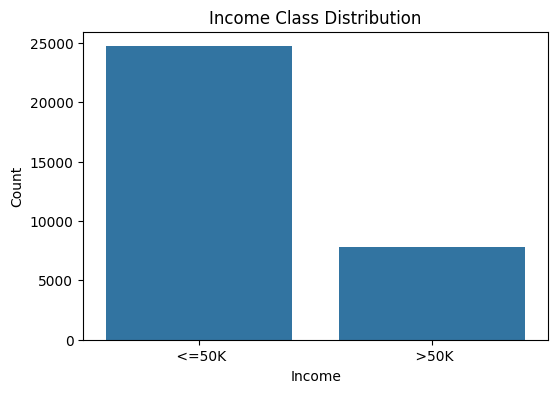

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

Percentage:
income
<=50K    75.907428
>50K     24.092572
Name: proportion, dtype: float64


In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_cleaned, x="income")
plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

print(df_cleaned["income"].value_counts())
print("\nPercentage:")
print(df_cleaned["income"].value_counts(normalize=True) * 100)

## 9. Numerical Feature Distributions

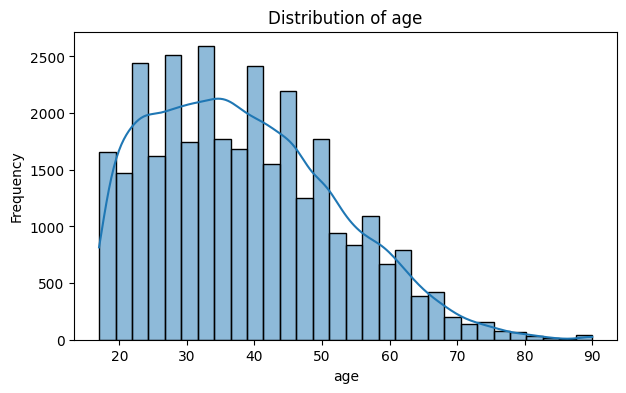

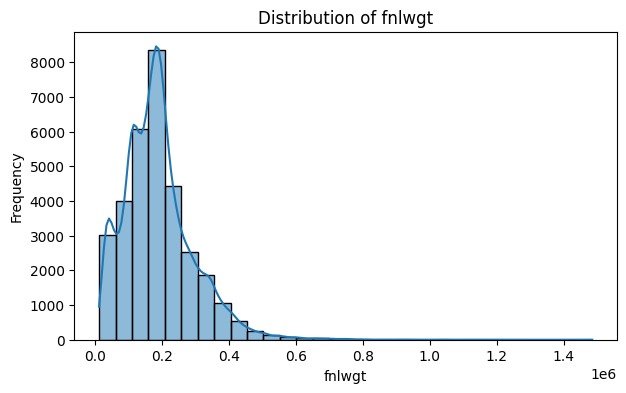

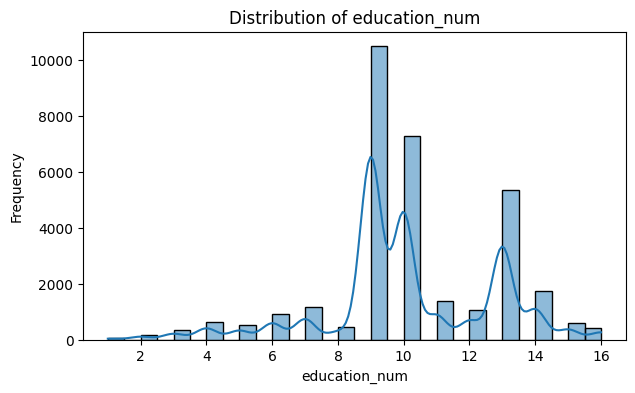

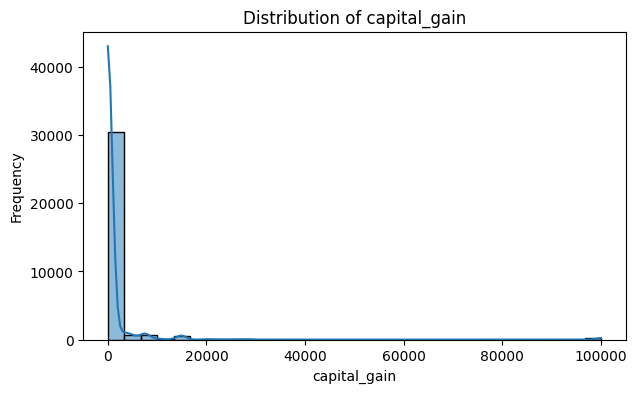

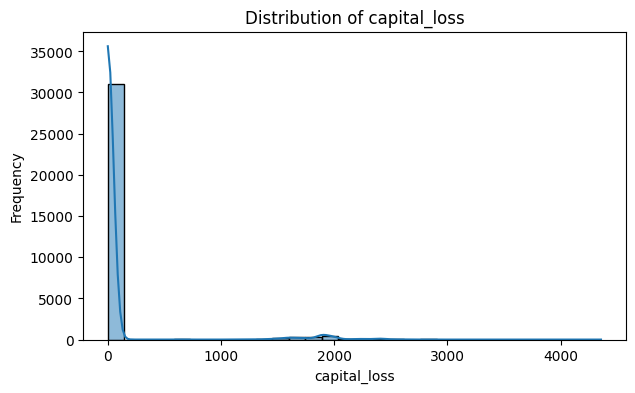

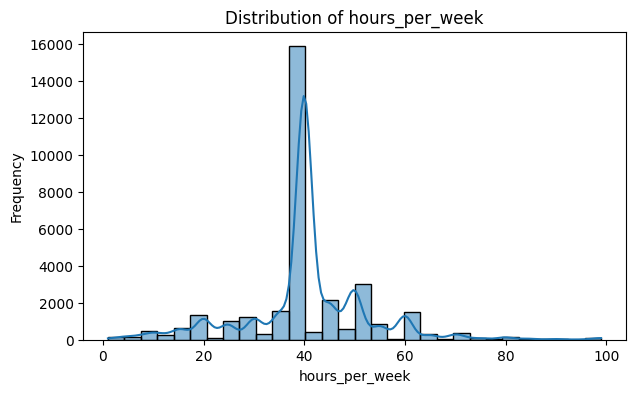

In [14]:
numerical_cols = df_cleaned.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df_cleaned[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 10. Boxplots for Numerical Features

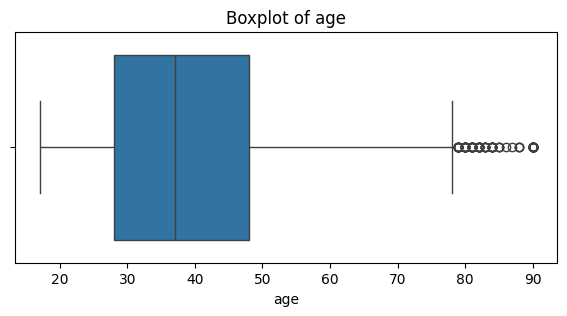

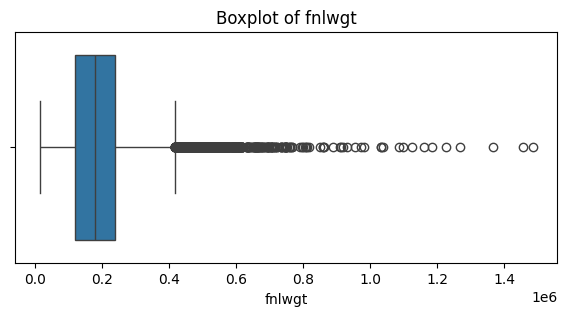

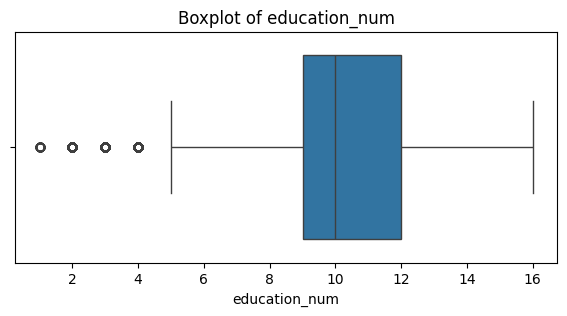

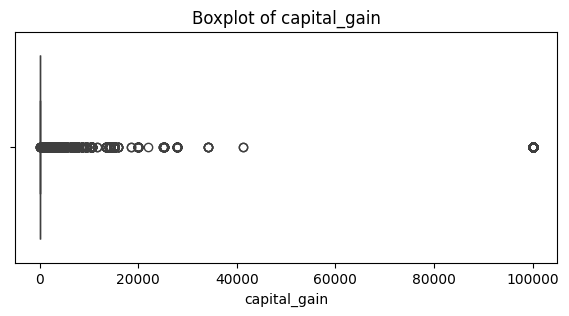

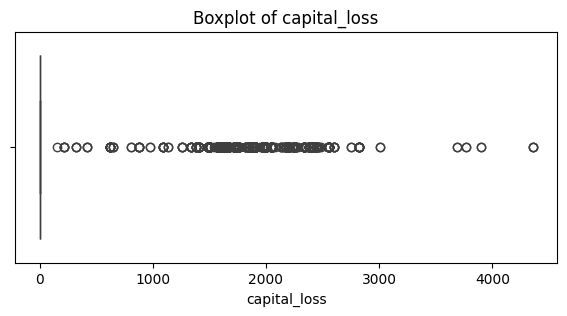

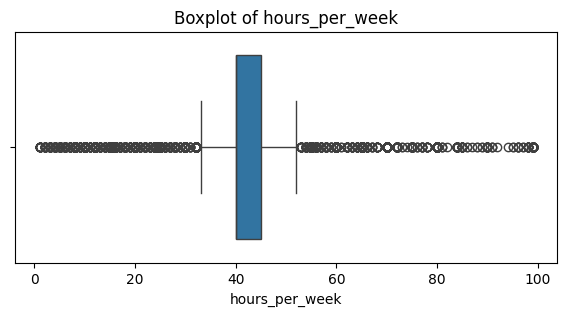

In [15]:
for col in numerical_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df_cleaned[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 11. Categorical Feature Countplots

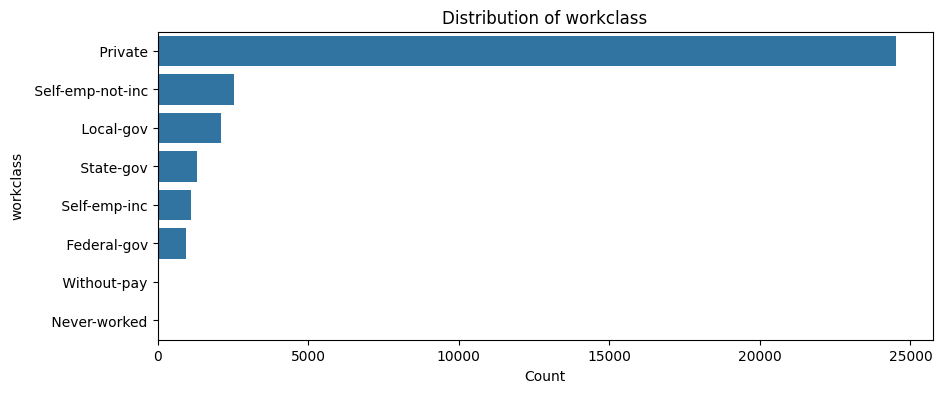

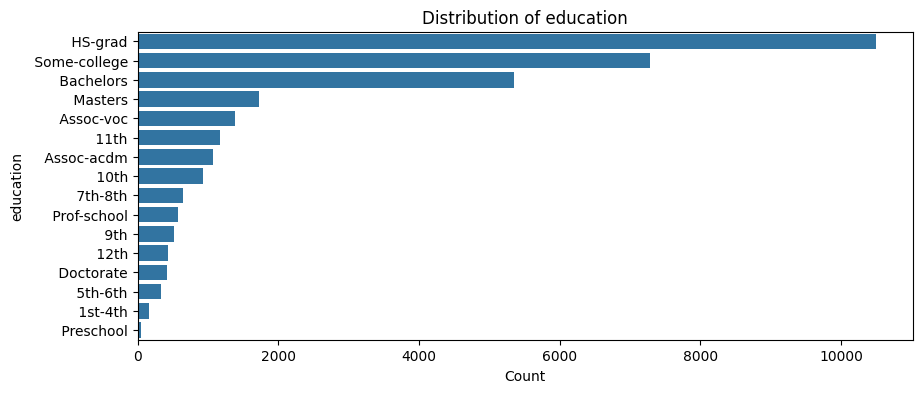

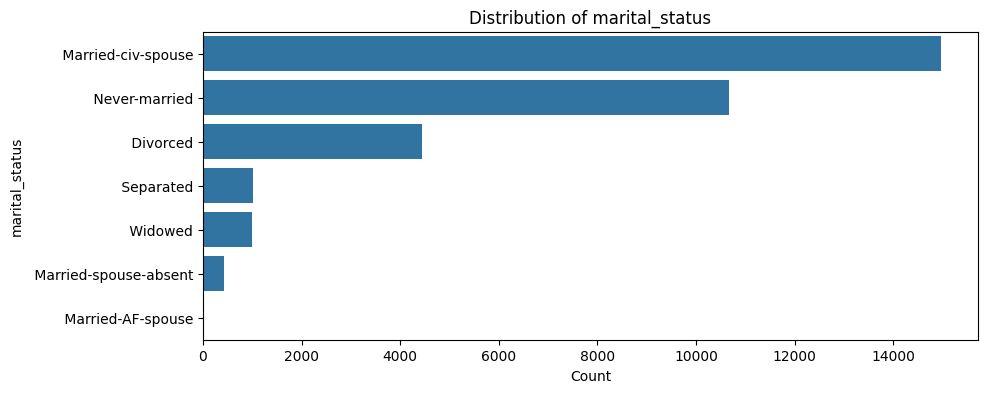

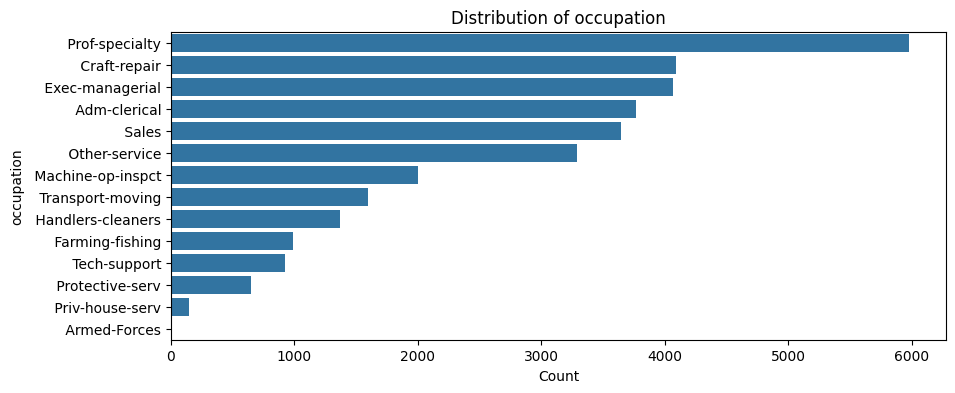

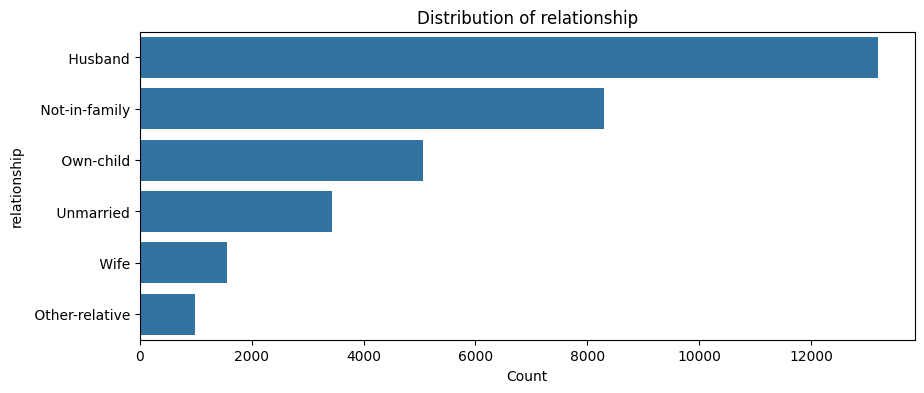

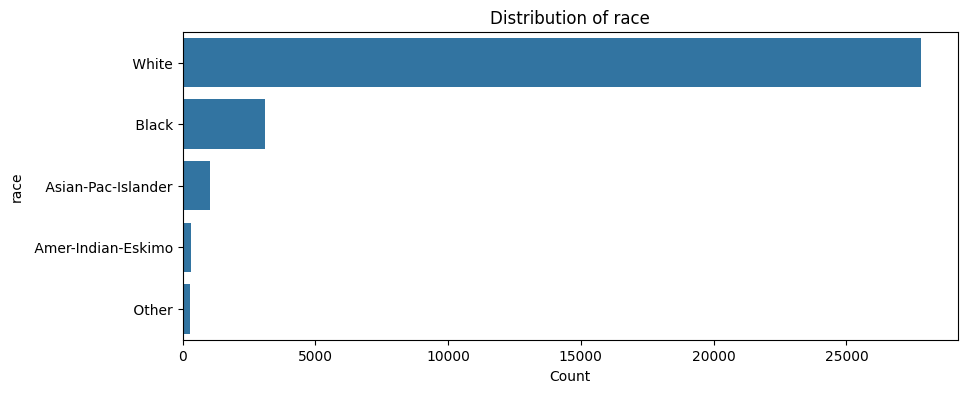

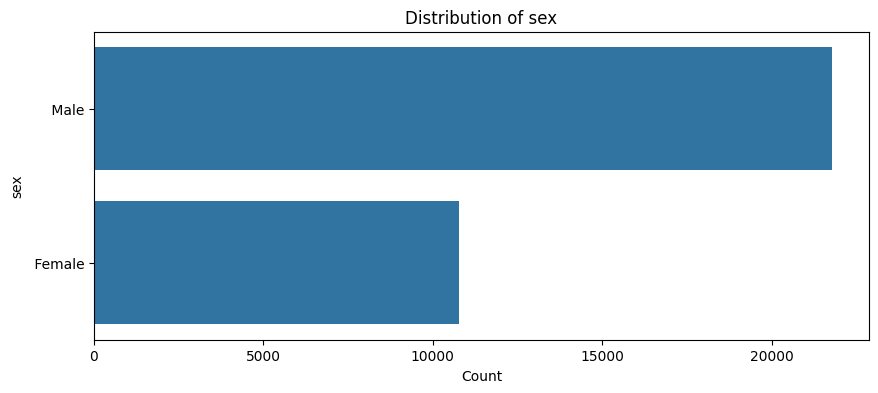

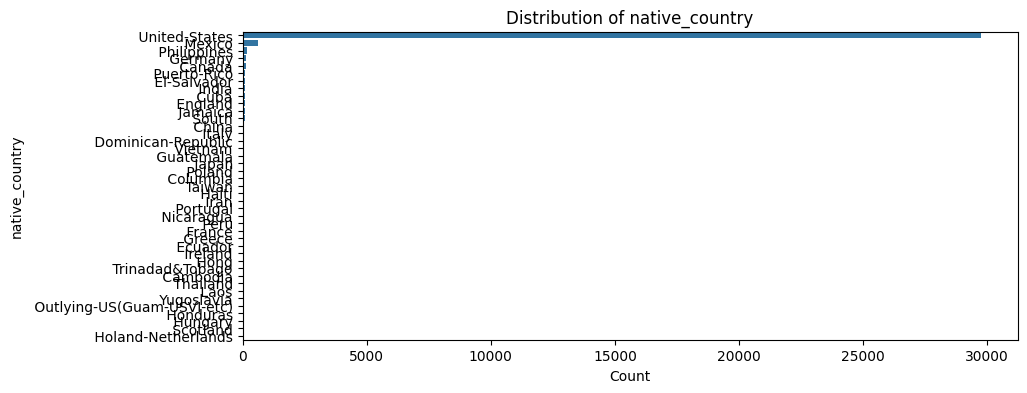

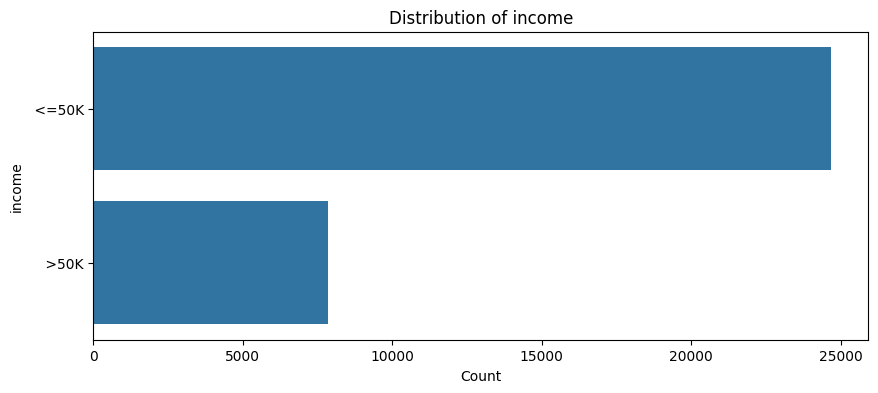

In [16]:
categorical_cols = df_cleaned.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df_cleaned, y=col, order=df_cleaned[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

# Task 1: Scaling Techniques

## 12. Standard Scaling

Standard Scaling transforms data to have:

- Mean = 0
- Standard deviation = 1

Formula:

`z = (x - mean) / standard deviation`

Preferred when:
- Data follows approximately normal distribution.
- Algorithms are distance-based or gradient-based.
- Useful for Logistic Regression, SVM, KNN, PCA, Neural Networks.

In [17]:
standard_scaler = StandardScaler()

df_standard_scaled = df_cleaned.copy()
df_standard_scaled[numerical_cols] = standard_scaler.fit_transform(df_cleaned[numerical_cols])

print("Standard Scaled Numerical Features:")
display(df_standard_scaled[numerical_cols].head())

print("Mean after standard scaling:")
display(df_standard_scaled[numerical_cols].mean())

print("Standard deviation after standard scaling:")
display(df_standard_scaled[numerical_cols].std())

Standard Scaled Numerical Features:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030390,-1.063569,1.134777,0.148292,-0.216743,-0.035664
1,0.836973,-1.008668,1.134777,-0.145975,-0.216743,-2.222483
2,-0.042936,0.245040,-0.420679,-0.145975,-0.216743,-0.035664
3,1.056950,0.425752,-1.198407,-0.145975,-0.216743,-0.035664
4,-0.776193,1.408066,1.134777,-0.145975,-0.216743,-0.035664


Mean after standard scaling:


age              -7.555945e-17
fnlwgt           -1.255685e-16
education_num     2.849858e-17
capital_gain      3.646945e-17
capital_loss      4.367598e-19
hours_per_week   -6.485884e-17
dtype: float64

Standard deviation after standard scaling:


age               1.000015
fnlwgt            1.000015
education_num     1.000015
capital_gain      1.000015
capital_loss      1.000015
hours_per_week    1.000015
dtype: float64

## 13. Min-Max Scaling

Min-Max Scaling transforms data into a fixed range, usually 0 to 1.

Formula:

`x_scaled = (x - min) / (max - min)`

Preferred when:
- We need values in a fixed range.
- Data does not necessarily follow normal distribution.
- Useful for Neural Networks and algorithms where bounded input is helpful.

In [18]:
minmax_scaler = MinMaxScaler()

df_minmax_scaled = df_cleaned.copy()
df_minmax_scaled[numerical_cols] = minmax_scaler.fit_transform(df_cleaned[numerical_cols])

print("Min-Max Scaled Numerical Features:")
display(df_minmax_scaled[numerical_cols].head())

print("Minimum values after Min-Max scaling:")
display(df_minmax_scaled[numerical_cols].min())

print("Maximum values after Min-Max scaling:")
display(df_minmax_scaled[numerical_cols].max())

Min-Max Scaled Numerical Features:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


Minimum values after Min-Max scaling:


age               0.0
fnlwgt            0.0
education_num     0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
dtype: float64

Maximum values after Min-Max scaling:


age               1.0
fnlwgt            1.0
education_num     1.0
capital_gain      1.0
capital_loss      1.0
hours_per_week    1.0
dtype: float64

## 14. Standard Scaling vs Min-Max Scaling Discussion

### Standard Scaling
Standard Scaling is preferred when the data has outliers or follows a normal-like distribution. It does not bound values between 0 and 1, but centers them around zero.

### Min-Max Scaling
Min-Max Scaling is preferred when we want all values in a fixed range. However, it is sensitive to outliers because extreme values can affect the scaling range.

### Difference

| Point | Standard Scaling | Min-Max Scaling |
|---|---|---|
| Output range | Not fixed | Usually 0 to 1 |
| Based on | Mean and standard deviation | Minimum and maximum |
| Sensitive to outliers | Less sensitive | More sensitive |
| Useful for | SVM, KNN, Logistic Regression, PCA | Neural Networks, image processing |

# Task 2: Encoding Techniques

## 15. Identify Categorical Columns for Encoding

Assignment rule:

- Apply One-Hot Encoding to categorical variables with less than 5 categories.
- Apply Label Encoding to categorical variables with more than 5 categories.

In [19]:
categorical_cols = df_cleaned.select_dtypes(include=["object"]).columns.tolist()

# Exclude target column from feature encoding for now
categorical_feature_cols = [col for col in categorical_cols if col != "income"]

one_hot_cols = []
label_encode_cols = []

for col in categorical_feature_cols:
    unique_count = df_cleaned[col].nunique()

    if unique_count < 5:
        one_hot_cols.append(col)
    else:
        label_encode_cols.append(col)

print("Categorical feature columns:")
print(categorical_feature_cols)

print("\nOne-Hot Encoding columns less than 5 categories:")
print(one_hot_cols)

print("\nLabel Encoding columns more than 5 categories:")
print(label_encode_cols)

Categorical feature columns:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

One-Hot Encoding columns less than 5 categories:
['sex']

Label Encoding columns more than 5 categories:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


## 16. Apply One-Hot Encoding and Label Encoding

In [20]:
df_encoded = df_cleaned.copy()

# Label encode categorical columns with more than 5 categories
label_encoders = {}

for col in label_encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# One-hot encode categorical columns with less than 5 categories
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=True)

# Encode target column income
target_encoder = LabelEncoder()
df_encoded["income"] = target_encoder.fit_transform(df_encoded["income"])

print("Shape after encoding:", df_encoded.shape)
display(df_encoded.head())

Shape after encoding: (32537, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Male
0,39,6,77516,9,13,4,0,1,4,2174,0,40,38,0,True
1,50,5,83311,9,13,2,3,0,4,0,0,13,38,0,True
2,38,3,215646,11,9,0,5,1,4,0,0,40,38,0,True
3,53,3,234721,1,7,2,5,0,2,0,0,40,38,0,True
4,28,3,338409,9,13,2,9,5,2,0,0,40,4,0,False


## 17. Pros and Cons of One-Hot Encoding and Label Encoding

### One-Hot Encoding

Pros:
1. Does not create false order among categories.
2. Good for nominal categorical variables.
3. Works well with linear models.

Cons:
1. Increases number of columns.
2. Can create high-dimensional data.
3. Not efficient for variables with many categories.

### Label Encoding

Pros:
1. Simple and memory efficient.
2. Does not increase number of columns.
3. Useful for categorical variables with many categories.

Cons:
1. Creates artificial numeric order.
2. May mislead some models into assuming one category is greater than another.
3. Not ideal for nominal variables in linear models.

# Task 3: Feature Engineering

## 18. Create New Features

We create at least 2 new features:

### Feature 1: `capital_net`
`capital_net = capital_gain - capital_loss`

Rationale:
This represents net capital benefit or loss of a person.

### Feature 2: `work_intensity`
`work_intensity = hours_per_week / age`

Rationale:
This gives an idea of working hours relative to age.

### Feature 3: `education_age_ratio`
`education_age_ratio = education_num / age`

Rationale:
This represents education level compared to age.

In [21]:
df_features = df_cleaned.copy()

df_features["capital_net"] = df_features["capital_gain"] - df_features["capital_loss"]
df_features["work_intensity"] = df_features["hours_per_week"] / (df_features["age"] + 1)
df_features["education_age_ratio"] = df_features["education_num"] / (df_features["age"] + 1)

display(df_features[["capital_gain", "capital_loss", "capital_net", "hours_per_week", "age", "work_intensity", "education_num", "education_age_ratio"]].head())

,capital_gain,capital_loss,capital_net,hours_per_week,age,work_intensity,education_num,education_age_ratio
0,2174,0,2174,40,39,1.000000,13,0.325000
1,0,0,0,13,50,0.254902,13,0.254902
2,0,0,0,40,38,1.025641,9,0.230769
3,0,0,0,40,53,0.740741,7,0.129630
4,0,0,0,40,28,1.379310,13,0.448276


## 19. Skewness Analysis

We check skewness of numerical features to decide where log transformation is useful.

Highly skewed variables can benefit from log transformation.

In [22]:
skewness = df_features.select_dtypes(include=["int64", "float64"]).skew().sort_values(ascending=False)

print("Skewness of numerical features:")
display(skewness)

Skewness of numerical features:


capital_gain           11.949403
capital_net            11.867499
capital_loss            4.592702
fnlwgt                  1.447703
work_intensity          0.719479
age                     0.557663
education_age_ratio     0.265577
hours_per_week          0.228759
education_num          -0.309500
dtype: float64

## 20. Apply Log Transformation

`capital_gain` is often highly skewed because many people have zero capital gain while few have very high values.

We apply:

`log_capital_gain = log1p(capital_gain)`

`log1p` is used because it handles zero values safely.

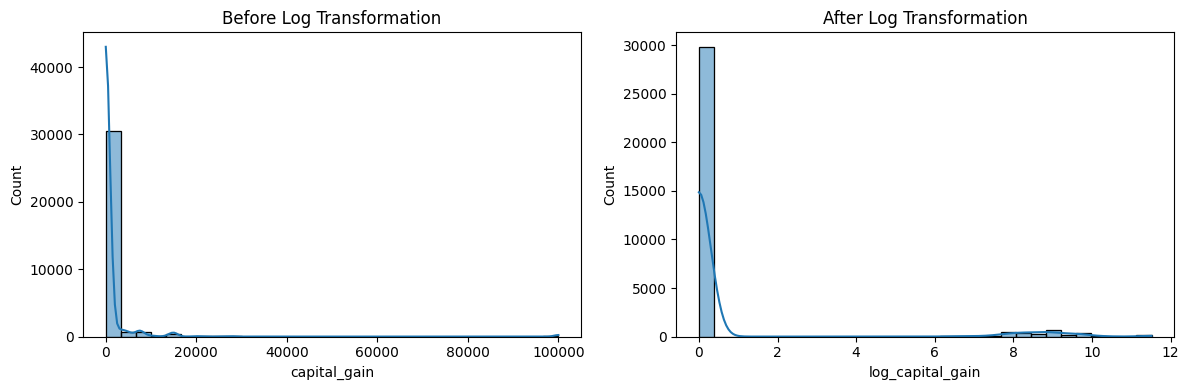

Skewness before log transformation: 11.949402833551463
Skewness after log transformation: 3.094666793136126


In [23]:
df_features["log_capital_gain"] = np.log1p(df_features["capital_gain"])

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df_features["capital_gain"], bins=30, kde=True)
plt.title("Before Log Transformation")

plt.subplot(1,2,2)
sns.histplot(df_features["log_capital_gain"], bins=30, kde=True)
plt.title("After Log Transformation")

plt.tight_layout()
plt.show()

print("Skewness before log transformation:", df_features["capital_gain"].skew())
print("Skewness after log transformation:", df_features["log_capital_gain"].skew())

# Task 4: Feature Selection

## 21. Isolation Forest for Outlier Detection

Isolation Forest identifies outliers by isolating observations.

Outliers can affect model performance by:
1. Distorting feature scaling.
2. Increasing model error.
3. Making decision boundaries unstable.
4. Reducing generalization performance.

In [24]:
# For Isolation Forest, use encoded numerical dataset
df_iforest = df_features.copy()

# Encode all categorical columns for Isolation Forest
for col in df_iforest.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df_iforest[col] = le.fit_transform(df_iforest[col])

# Separate target if present
X_iforest = df_iforest.drop(columns=["income"])

# Scale features
scaler_iforest = StandardScaler()
X_iforest_scaled = scaler_iforest.fit_transform(X_iforest)

# Apply Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

outlier_labels = iso_forest.fit_predict(X_iforest_scaled)

# -1 means outlier, 1 means normal
df_features["outlier"] = outlier_labels

print("Outlier Count:")
print(df_features["outlier"].value_counts())

# Remove outliers
df_no_outliers = df_features[df_features["outlier"] == 1].drop(columns=["outlier"])

print("\nOriginal Shape:", df_features.shape)
print("Shape after removing outliers:", df_no_outliers.shape)

Outlier Count:
outlier
 1    30910
-1     1627
Name: count, dtype: int64

Original Shape: (32537, 20)
Shape after removing outliers: (30910, 19)


## 22. Visualize Outliers

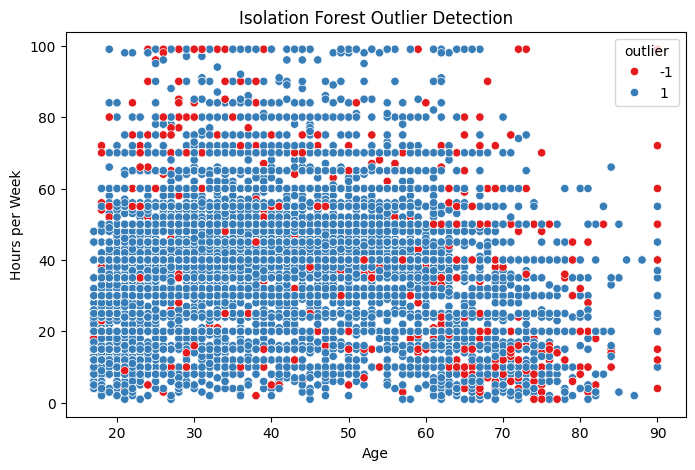

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_features,
    x="age",
    y="hours_per_week",
    hue="outlier",
    palette="Set1"
)
plt.title("Isolation Forest Outlier Detection")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.show()

## 23. Correlation Matrix

Correlation measures only linear relationships between numerical variables.

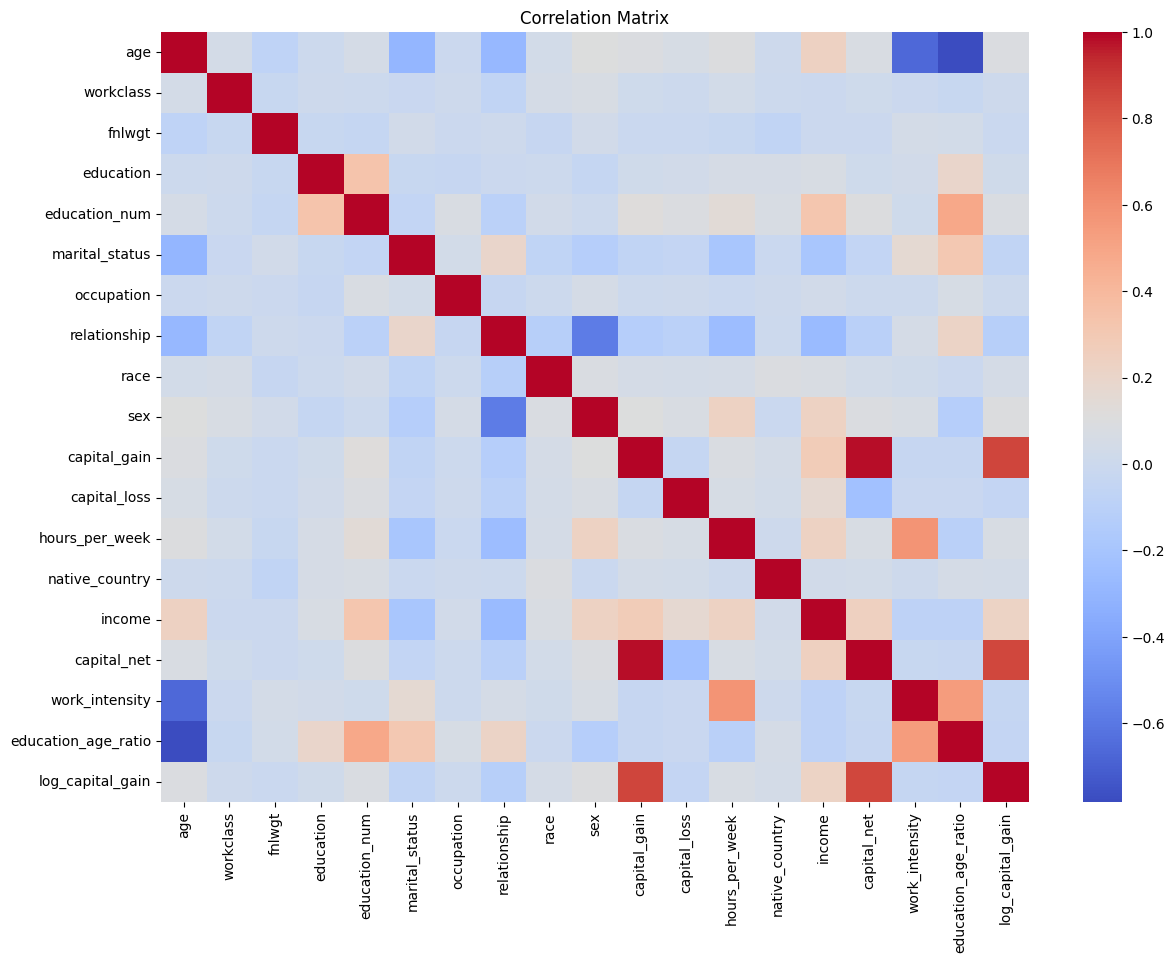

Correlation with income:


income                 1.000000
education_num          0.319971
capital_gain           0.279944
capital_net            0.242209
age                    0.236268
sex                    0.229165
hours_per_week         0.229136
log_capital_gain       0.225271
capital_loss           0.165643
race                   0.080532
education              0.070020
occupation             0.031978
native_country         0.028533
workclass             -0.003191
fnlwgt                -0.008600
work_intensity        -0.079648
education_age_ratio   -0.082164
marital_status        -0.196742
relationship          -0.273966
Name: income, dtype: float64

In [26]:
# Encode target and categorical columns for correlation
df_corr = df_no_outliers.copy()

for col in df_corr.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col])

plt.figure(figsize=(14,10))
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

print("Correlation with income:")
display(corr_matrix["income"].sort_values(ascending=False))

## 24. PPS Score Analysis

PPS stands for Predictive Power Score.

Unlike correlation:
- PPS can detect non-linear relationships.
- PPS works with both numerical and categorical variables.
- PPS is asymmetric, meaning PPS(A predicts B) may not equal PPS(B predicts A).

In [27]:
# PPS may take some time
pps_matrix = pps.matrix(df_no_outliers)

display(pps_matrix.head())

# PPS scores for predicting income
pps_income = pps_matrix[pps_matrix["y"] == "income"].sort_values(by="ppscore", ascending=False)

print("Top PPS scores for predicting income:")
display(pps_income.head(15))

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.000000,predict_itself,True,None,0.000000,1.000000,None
1,age,workclass,0.000000,classification,True,weighted F1,0.651493,0.651297,DecisionTreeClassifier()
2,age,fnlwgt,0.000000,regression,True,mean absolute error,75877.736000,76910.043855,DecisionTreeRegressor()
3,age,education,0.053395,classification,True,weighted F1,0.197800,0.240633,DecisionTreeClassifier()
4,age,education_num,0.000000,regression,True,mean absolute error,1.802000,1.856059,DecisionTreeRegressor()


Top PPS scores for predicting income:


,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
280,income,income,1.000000e+00,predict_itself,True,None,0.000000,1.000000,None
299,capital_net,income,3.178031e-01,classification,True,weighted F1,0.664775,0.771310,DecisionTreeClassifier()
71,education,income,2.182556e-01,classification,True,weighted F1,0.664775,0.737939,DecisionTreeClassifier()
90,education_num,income,2.182556e-01,classification,True,weighted F1,0.664775,0.737939,DecisionTreeClassifier()
204,capital_gain,income,2.118397e-01,classification,True,weighted F1,0.664775,0.735789,DecisionTreeClassifier()
356,log_capital_gain,income,2.118397e-01,classification,True,weighted F1,0.664775,0.735789,DecisionTreeClassifier()
337,education_age_ratio,income,1.915429e-01,classification,True,weighted F1,0.664775,0.728985,DecisionTreeClassifier()
223,capital_loss,income,1.319885e-01,classification,True,weighted F1,0.664775,0.709020,DecisionTreeClassifier()
318,work_intensity,income,7.366415e-02,classification,True,weighted F1,0.664775,0.689469,DecisionTreeClassifier()
33,workclass,income,3.782945e-02,classification,True,weighted F1,0.664775,0.677456,DecisionTreeClassifier()


## 25. PPS Matrix Heatmap

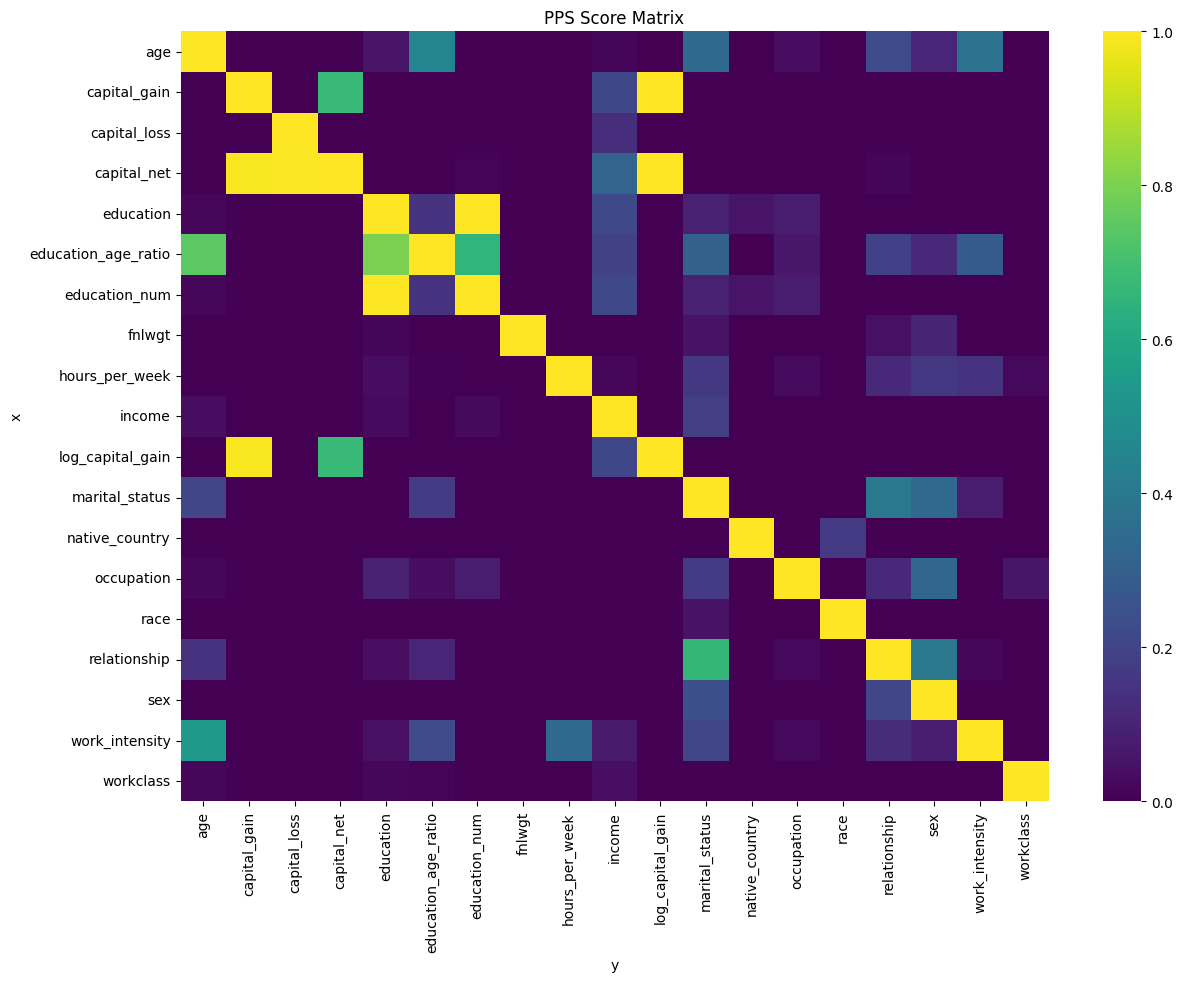

In [28]:
pps_pivot = pps_matrix.pivot(index="x", columns="y", values="ppscore")

plt.figure(figsize=(14,10))
sns.heatmap(pps_pivot, cmap="viridis", annot=False)
plt.title("PPS Score Matrix")
plt.show()

## 26. PPS vs Correlation Comparison

### Correlation Matrix
- Measures linear relationships.
- Works mainly with numerical variables.
- Values range from -1 to +1.
- Cannot detect many non-linear relationships.

### PPS Score
- Measures predictive power.
- Works with numerical and categorical variables.
- Values range from 0 to 1.
- Can detect non-linear relationships.
- Is asymmetric.

### Observation
Correlation may show limited relationships with income because income is categorical. PPS is more useful here because it can evaluate how well each feature predicts the target income.

## 27. Final Preprocessed Dataset

Now we create a final processed version after:

1. Missing value handling  
2. Feature engineering  
3. Outlier removal  
4. Encoding

In [29]:
final_df = df_no_outliers.copy()

# Encode all categorical columns
for col in final_df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    final_df[col] = le.fit_transform(final_df[col])

print("Final Dataset Shape:", final_df.shape)
display(final_df.head())

final_df.to_csv("adult_preprocessed_final.csv", index=False)

print("Final preprocessed dataset saved as adult_preprocessed_final.csv")

Final Dataset Shape: (30910, 19)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_net,work_intensity,education_age_ratio,log_capital_gain
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,37,0,2174,1.000000,0.325000,7.684784
1,50,5,83311,9,13,2,3,0,4,1,0,0,13,37,0,0,0.254902,0.254902,0.000000
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,37,0,0,1.025641,0.230769,0.000000
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,37,0,0,0.740741,0.129630,0.000000
5,37,3,284582,12,14,2,3,5,4,0,0,0,40,37,0,0,1.052632,0.368421,0.000000


Final preprocessed dataset saved as adult_preprocessed_final.csv


## 28. Final Conclusion

In this assignment, the Adult dataset was used to apply data preprocessing, feature engineering, and feature selection techniques.

First, the dataset was loaded and explored using summary statistics, data types, missing values, and visualizations. Missing values represented by `?` were replaced with NaN and handled using mode or median imputation.

Scaling techniques were applied to numerical features using Standard Scaling and Min-Max Scaling. Standard Scaling is useful when features need to be centered around zero, while Min-Max Scaling is useful when values need to be transformed into a fixed range.

Categorical variables were encoded using the assignment rule: One-Hot Encoding for variables with fewer than 5 categories and Label Encoding for variables with more than 5 categories. The advantages and disadvantages of both methods were discussed.

New features such as `capital_net`, `work_intensity`, and `education_age_ratio` were created to improve the predictive information in the dataset. Log transformation was applied to `capital_gain` because it was highly skewed.

Isolation Forest was used to identify and remove outliers. Finally, PPS score analysis was performed and compared with correlation analysis. PPS was found to be more flexible because it can detect non-linear relationships and can work with categorical variables.

Overall, this assignment demonstrates the importance of preprocessing, feature engineering, scaling, encoding, outlier treatment, and feature selection before building machine learning models.